# What is Machine Learning? Why is it Required?

This notebook introduces the idea of machine learning in a beginner-friendly way and shows how a simple model works on the real Iris dataset from scikit-learn.

## Notebook objective
- Understand what machine learning is.
- Learn why machine learning is needed in modern technology.
- Explore a real dataset and train a simple classifier.

## Learning outcomes
By the end of this notebook, you should be able to:
- explain the basic idea of machine learning;
- describe why data is important;
- load and inspect a real dataset;
- train and evaluate a simple model;
- interpret basic results for interviews and projects.

## Prerequisites
- Basic Python knowledge
- Familiarity with Jupyter notebooks
- Interest in AI, data science, and real-world applications

## Dataset description
We will use the famous Iris flower dataset, which contains measurements of sepals and petals for three species of iris flowers.

The same dataset is also available on Kaggle:
https://www.kaggle.com/datasets/uciml/iris

## Credits
This notebook is designed for first-year B.Tech students and interview preparation. It uses the Iris dataset from scikit-learn.

## Why this code cell is needed
This section prepares the notebook for analysis and model building. It brings in the Python tools for working with data, creating charts, and training a classifier.

## What this code does
- Imports NumPy and Pandas for numeric and tabular data handling.
- Imports Matplotlib and Seaborn for visualization.
- Imports the Iris dataset and machine learning utilities from scikit-learn.
- Sets a fixed random seed so the results are repeatable.

## What you should understand before running it
- Basic Python imports
- The idea of a random seed in experiments
- Why visualization and modeling libraries are useful in ML

## Expected output
This cell usually shows no visible result, but it makes all the required tools available for the rest of the notebook.

In [8]:
# Import libraries for numeric work, data handling, visualization, and machine learning.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the real Iris dataset and the tools needed to build a simple classifier.
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# INTERVIEW NOTE: These libraries are the standard Python stack for data science interviews.
# INTERVIEW NOTE: random_state is a common concept asked in interviews because it makes results reproducible.
# Keep the random state fixed so the results are repeatable.
np.random.seed(42)

# Show charts inline in the notebook.

%matplotlib inline

## Theory recap
- What is Machine Learning? It is a method where computers learn patterns from data instead of using fixed rules.
- Why is Machine Learning required? It helps solve complex problems such as spam detection, recommendation systems, disease prediction, and image analysis.
- AI vs ML: AI is the broad field of making machines smart, while ML is one way to achieve AI by learning from data.
- Types of ML: supervised, unsupervised, and reinforcement learning.
- Real-world applications: email filtering, fraud detection, voice assistants, medical diagnosis, and self-driving systems.

## Why data loading matters
Loading data is the first real step in any machine learning project. If data is not loaded correctly, the model cannot learn meaningful patterns. In this notebook, we use the real Iris dataset from scikit-learn, which is trusted and beginner-friendly.

## Why this code cell is needed
This section is important because real machine learning starts with loading and inspecting the actual dataset. We need to confirm that the data is available in the correct format before training any model.

## What this code does
- Loads the Iris dataset directly from scikit-learn.
- Converts it into a Pandas DataFrame.
- Shows the first rows, dataset information, and summary statistics.
- Prints the feature names, classes, sample count, and feature count.

## What you should understand before running it
- The difference between features and labels
- What a DataFrame is in Pandas
- Why checking a dataset is the first step in machine learning

## Expected output
You should see a small table of the first records, a summary of the dataset structure, and simple statistics such as means and ranges.

In [9]:
# Load the Iris dataset directly from scikit-learn as a DataFrame.
# INTERVIEW NOTE: Using a real dataset like Iris is often preferred in interviews because it shows practical understanding.
iris = load_iris(as_frame=True)
df = iris.frame

print('FIRST 5 ROWS OF THE DATASET')
print(df.head())
print('\n')

print('DATASET INFORMATION')
df.info()
print('\n')

print('STATISTICAL SUMMARY')
print(df.describe())
print('\n')

print('FEATURE NAMES:', list(df.columns[:-1]))
print('TARGET CLASSES:', iris.target_names.tolist())
print('NUMBER OF SAMPLES:', df.shape[0])
print('NUMBER OF FEATURES:', df.shape[1] - 1)


FIRST 5 ROWS OF THE DATASET
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target           

## What this output shows
The dataset output gives you the first rows, the structure of the table, and summary statistics for each feature.

## How to interpret it
- The first rows show what the data looks like in practice.
- The information table tells you how many rows and columns exist and whether any values are missing.
- The summary statistics describe the spread and range of each measurement.

## Why it matters
This helps you confirm that the dataset is real, usable, and suitable for model training.

## Higher or lower values?
For these statistics, there is no single “better” value. The goal is to understand the data well enough to judge whether the features are meaningful and balanced.

## Preprocessing and why it matters
Before training a model, we usually check the data for missing values, duplicates, and inconsistent formats. This step helps the model learn better and avoids strange or unreliable results.

## Why this code cell is needed
This step checks the quality of the dataset. If the data contains missing values or duplicates, the model can learn from unreliable information.

## What this code does
- Counts missing values in every column.
- Counts duplicate rows.
- Separates the input features and the target label.

## What you should understand before running it
- What a missing value means
- What a duplicate row is
- The difference between input features and target output

## Expected output
You should see a summary of missing values, the number of duplicates, and the shapes of the feature table and target column.

In [10]:
# Check for missing values in every column.
missing_values = df.isnull().sum()
print('MISSING VALUES PER COLUMN')
print(missing_values)
print('\n')

# Check for duplicate rows in the dataset.
duplicate_rows = df.duplicated().sum()
print('NUMBER OF DUPLICATE ROWS:', duplicate_rows)

# Prepare features and target for model training.
X = df.drop('target', axis=1)
y = df['target']

print('FEATURE MATRIX SHAPE:', X.shape)
print('TARGET VECTOR SHAPE:', y.shape)


MISSING VALUES PER COLUMN
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


NUMBER OF DUPLICATE ROWS: 1
FEATURE MATRIX SHAPE: (150, 4)
TARGET VECTOR SHAPE: (150,)


## What this output shows
This output tells you whether the dataset has missing values or repeated rows and how the feature/target split is shaped.

## How to interpret it
- Missing values should ideally be zero for a clean dataset.
- Duplicate rows may reduce the trustworthiness of the data if they appear too often.
- The feature matrix and target vector sizes show how the model will receive input and output information.

## Why it matters
Cleaning and understanding the data is an important step before training a model.

## Higher or lower values?
For missing values and duplicates, lower is always better. For the shapes, the important part is that the data has the expected dimensions for training.

## Inputs, outputs, parameters, predictions, errors, and loss
- Inputs: the features used to make a decision.
- Outputs: the class label or value the model tries to predict.
- Parameters: the learned weights and biases inside the model.
- Predictions: the model's estimated outputs for new data.
- Errors: the difference between the real answer and the predicted answer.
- Loss: a number that measures how wrong the predictions are on average.

## Why this code cell is needed
This example helps learners understand the basic idea behind prediction and error in machine learning without using a complex model.

## What this code does
- Creates a simple input array and expected output array.
- Uses a basic rule to predict values.
- Computes the Mean Squared Error (MSE) to measure prediction error.

## What you should understand before running it
- What an input feature is
- What a prediction is
- The meaning of error and loss in ML

## Expected output
You should see the input values, the predicted values, the real values, and a loss value of 0.0 for this simple example.

In [11]:
# Simple NumPy example to understand prediction and loss.
# INTERVIEW NOTE: This is a basic intuition; real models use many more steps and parameters.
# INTERVIEW NOTE: Mean Squared Error (MSE) is a standard loss function asked in interview discussions on regression and optimization.
x = np.array([1, 2, 3, 4])
y_true = np.array([2, 4, 6, 8])

# A simple rule: output is always twice the input.
def predict(x):
    return 2 * x

# Mean squared error (MSE) measures the average squared difference.
def mse(actual, pred):
    return np.mean((actual - pred) ** 2)

pred = predict(x)
loss = mse(y_true, pred)

print('INPUT VALUES:', x)
print('PREDICTIONS:', pred)
print('ACTUAL VALUES:', y_true)
print('LOSS (MSE):', loss)


INPUT VALUES: [1 2 3 4]
PREDICTIONS: [2 4 6 8]
ACTUAL VALUES: [2 4 6 8]
LOSS (MSE): 0.0


## What this output shows
This small example shows the model's input values, its predicted values, the real target values, and the resulting loss.

## How to interpret it
- The predictions are generated by the simple rule 2 × x.
- The loss is the average squared difference between the real values and the predictions.
- In this case, the loss is 0.0 because the rule matches the real pattern perfectly.

## Why it matters
This gives intuition for how machine learning measures error and why lower loss is desirable.

## Higher or lower values?
For MSE, lower is better because it means the predictions are closer to the true values.

## Understanding Mean Squared Error (MSE)
MSE is a simple way to measure how far a model's predictions are from the real answers. It adds up the squared differences and then takes the average, so smaller values mean better predictions.

### How to interpret MSE
- Low MSE: the predictions are close to the actual values, which usually means the model is performing well on that example.
- High MSE: the predictions are far away from the true values, which means the model is making larger errors.

### Real-world analogy
Think of MSE like measuring how far your arrows land from the center of a target. If most arrows are near the center, the error is small. If they land far away, the error is large.

### Why minimizing loss matters
In machine learning, the model learns by trying to reduce loss. A lower loss usually means the model is improving and making more accurate predictions, which is the main goal of training.

## Why use scikit-learn?
Writing every machine learning algorithm from scratch is possible, but it takes a lot of time and effort. Scikit-learn gives tested, efficient, and beginner-friendly tools for loading data, training models, and evaluating results.

## Why this code cell is needed
This section shows how a real machine learning model is trained and evaluated on the Iris data. It connects the theory to a practical example.

## What this code does
- Splits the data into training and testing sets.
- Trains a Logistic Regression model.
- Makes predictions on unseen data.
- Prints the accuracy, classification report, and confusion matrix.

## What you should understand before running it
- Why we split data into train and test parts
- What a classifier does
- The difference between training and evaluation

## Expected output
You should see the number of training and testing samples, model accuracy, a full classification summary, and a confusion matrix.

In [12]:
# Split the dataset into training and testing parts.
# INTERVIEW NOTE: train_test_split is a common interview topic because it helps evaluate model performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a simple logistic regression model.
# INTERVIEW NOTE: Logistic Regression is a classic classification model that recruiters often ask about in beginner interviews.
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Make predictions on unseen test data.
pred = model.predict(X_test)

# Evaluate the model.
# INTERVIEW NOTE: Accuracy score measures how many predictions are correct, but interviewers may also ask about its limitations.
accuracy = accuracy_score(y_test, pred)
# INTERVIEW NOTE: Classification Report is important because it shows precision, recall, and F1-score for each class.
report = classification_report(y_test, pred, target_names=iris.target_names)
# INTERVIEW NOTE: Confusion Matrix helps explain true positives, false positives, true negatives, and false negatives.
cm = confusion_matrix(y_test, pred)

print('TRAINING SAMPLES:', X_train.shape[0])
print('TESTING SAMPLES:', X_test.shape[0])
print('ACCURACY:', accuracy)
print('\nCLASSIFICATION REPORT')
print(report)
print('\nCONFUSION MATRIX')
print(cm)

print('\nConceptually, this is similar to the NumPy example: the model learns parameters from data and then uses them to make predictions.')


TRAINING SAMPLES: 120
TESTING SAMPLES: 30
ACCURACY: 1.0

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


CONFUSION MATRIX
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Conceptually, this is similar to the NumPy example: the model learns parameters from data and then uses them to make predictions.


## What this output shows
This output reports how many samples were used for training and testing, the model's accuracy, the classification report, and the confusion matrix.

## How to interpret it
- Accuracy is the fraction of correct predictions on the test set.
- The classification report gives precision, recall, and F1-score for every class.
- The confusion matrix shows where the model was correct and where it confused one species with another.

## Why it matters
These metrics tell you whether the model is learning useful patterns and how reliable its predictions are on unseen data.

## Higher or lower values?
For accuracy, precision, recall, and F1-score, higher is better. For confusion matrix errors, lower counts of wrong predictions are better.

## Why this code cell is needed
This visualization section helps you see the pattern in the Iris dataset instead of reading only raw numbers. The bar chart shows whether each species appears in similar numbers, and the scatter plot shows whether the species form clear clusters based on petal and sepal length.

## What this code does
- Creates a class distribution chart using Seaborn.
- Uses a scatter plot to compare sepal length and petal length.
- Colors the points by species and adds readable titles, labels, and grid lines.

## What you should understand before running it
- What a class distribution is
- What x-axis and y-axis represent in a scatter plot
- Why visual patterns help in machine learning

## Insight to look for
- If the bar chart is balanced, the dataset has similar sample counts per class.
- If the scatter points separate well into color groups, the chosen features are informative for classification.

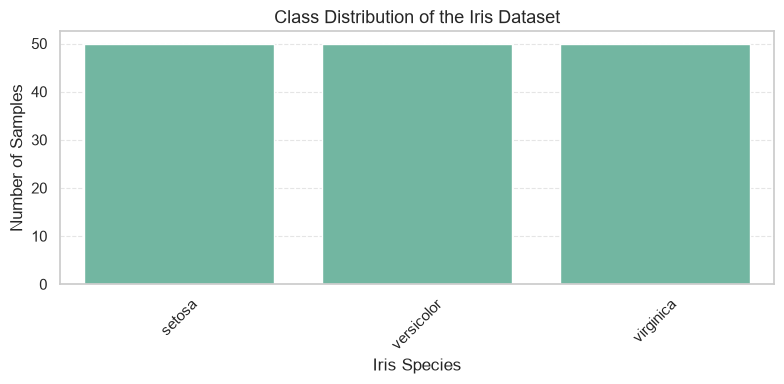

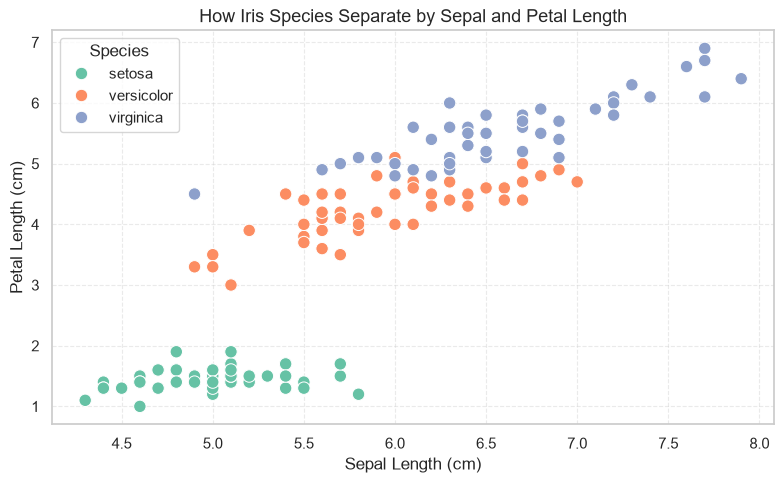

In [13]:
# Create a class distribution chart for the target labels.
sns.set_theme(style='whitegrid')
df['species'] = df['target'].map({0: iris.target_names[0], 1: iris.target_names[1], 2: iris.target_names[2]})

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x='species', color='#66c2a5')
ax.set_title('Class Distribution of the Iris Dataset', fontsize=13)
ax.set_xlabel('Iris Species')
ax.set_ylabel('Number of Samples')
ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Create a scatter plot using sepal length and petal length.
plt.figure(figsize=(8, 5))
ax = sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species',
    palette='Set2',
    s=80,
)
ax.set_title('How Iris Species Separate by Sepal and Petal Length', fontsize=13)
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
ax.grid(True, linestyle='--', linewidth=0.8, alpha=0.4)
ax.legend(title='Species')
plt.tight_layout()

plt.show()

## What this output shows
The charts visualize the class balance and the relationship between two key features in the Iris dataset.

## How to interpret it
- The bar chart shows whether the classes are evenly distributed across the dataset.
- The scatter plot shows how clearly the species separate when using sepal length and petal length.
- Strong visual separation often suggests the model will have an easier time learning patterns.

## Why it matters
Visualizations help you understand the data beyond raw numbers and can reveal patterns, class imbalance, or noise. A balanced dataset and distinct clusters usually make classification easier to learn.

## Higher or lower values?
There is no universal “better” value in the plots themselves, but clearer separation and balanced classes usually help the model perform better.

## Why this code cell is needed
This experiment section shows how small changes in training setup can influence the model's accuracy. It helps learners understand why careful choices matter in machine learning.

## What this code does
- Tries two different test sizes: 0.2 and 0.3.
- Tries two different iteration limits: 100 and 200.
- Prints the accuracy for each combination so you can compare the results.

## What you should understand before running it
- What train/test splitting means
- What random_state does in a reproducible experiment
- What max_iter means for model learning

## Expected output
You should see a set of accuracy values for each combination of test size and max_iter, which helps you compare how the model behaves under different settings.

In [14]:
# Compare how different train/test splits and iteration limits affect accuracy.
# INTERVIEW NOTE: This experiment shows how test_size, random_state, and max_iter affect model behavior and reproducibility.
for test_size in (0.2, 0.3):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    for max_iter in (100, 200):
        model = LogisticRegression(max_iter=max_iter, random_state=42)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, pred)
        print(f'test_size={test_size:.1f}, max_iter={max_iter}: accuracy = {accuracy:.4f}')


test_size=0.2, max_iter=100: accuracy = 1.0000
test_size=0.2, max_iter=200: accuracy = 1.0000
test_size=0.3, max_iter=100: accuracy = 1.0000
test_size=0.3, max_iter=200: accuracy = 1.0000


## What this output shows
This experiment compares how different train/test splits and iteration limits affect the model's accuracy.

## How to interpret it
- Smaller test sizes use more data for training, which can sometimes improve performance.
- Larger test sizes give a more realistic estimate of generalization.
- Higher max_iter allows the model more opportunity to learn, but it may not always change the result much.

## Why it matters
This shows why model choices and evaluation setup should be checked carefully rather than assumed.

## Higher or lower values?
For accuracy, higher is better. For test_size, the best choice depends on the trade-off between training and evaluation reliability.

## Interview Corner
- What is Machine Learning? It is the process of learning patterns from data to make predictions or decisions.
- Why is ML required? It helps solve problems that are too complex for fixed rules.
- AI vs ML: AI is the larger field; ML is a subset focused on data-driven learning.
- Supervised vs Unsupervised Learning: supervised uses labeled data, while unsupervised finds patterns in unlabeled data.
- Why split into train/test? We need a separate test set to measure real performance on unseen data.
- What is overfitting? It happens when the model memorizes training data and performs poorly on new data.

# Conclusion

Machine learning is important because it helps us solve real-world problems by learning patterns from data instead of relying only on hard-coded rules. In this notebook, students learned how data is loaded, inspected, cleaned, and split into training and testing sets. They also saw how a simple classifier makes predictions, how loss and accuracy are measured, and why visualizations help us understand the behavior of data and models.

Learning from data matters because the quality of the data directly affects the quality of the model. Good data helps us build models that are more reliable, while poor data can produce misleading results. This is why concepts such as data inspection, preprocessing, and evaluation are so important in machine learning.

This topic also connects naturally to other core ideas in the field:
- Bias: models can reflect unfair or unbalanced patterns in the data, so we must examine bias carefully.
- Regularization: techniques like regularization help prevent overfitting and make models generalize better.
- Feature Engineering: choosing or transforming the right input features can improve model performance.
- Cross-Validation: testing models across multiple data folds gives a stronger estimate of how well they will perform on unseen data.

Overall, this notebook is a beginner-friendly introduction to the machine learning pipeline and prepares students for more advanced topics in the next stages of the course.
